# Deep Learning Architectures for Pneumonia Detection: Multi-Scale Analysis with Explainable AI

**ResNet50 Fine-Tuned Models Notebook**

**Description:** This notebook fine-tunes the best performing ResNet50 model on higher resolution images (64x64) to improve performance for subsequent XAI analysis.

Authors:
- Rafaela Abrunhosa, 107658
- Miguel Pinto, 107449

In [1]:
# Clona apenas a branch fine_tuning
!git clone --branch fine_tuning --single-branch https://github.com/mariaabr/CAA_Project2.git

# Monta o Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Copia a pasta 'data' do Drive para o repositório
!cp -r /content/drive/MyDrive/data /content/CAA_Project2/

# Copia os modelos para o repositório
!cp -r /content/drive/MyDrive/models /content/CAA_Project2/output/


Cloning into 'CAA_Project2'...
remote: Enumerating objects: 428, done.
remote: Counting objects: 100% (101/101), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 428 (delta 50), reused 78 (delta 36), pack-reused 327 (from 1)
Receiving objects: 100% (428/428), 18.91 MiB | 16.84 MiB/s, done.
Resolving deltas: 100% (247/247), done.
Mounted at /content/drive


In [1]:
# Entra na pasta dos notebooks
%cd CAA_Project2/notebooks

/content/CAA_Project2/notebooks


# External Libraries

In [2]:
# Import utility libraries
import os
import sys
import time
from datetime import datetime
sys.path.append('..')  # Add parent directory to path to allow import of custom modules

# Import deep learning libraries
import tensorflow as tf

# Suppress TensorFlow warnings
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'    # 0=all, 1=info, 2=warning, 3=error
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'   # Disable oneDNN optimizations for reproducibility

# Disable verbose output from TensorFlow during training
tf_verbosity = 1  # 0 = silent, 1 = progress bar, 2 = one line per epoch

# Import custom utilities
from utils.data_utils import load_and_preprocess_multiscale_data
from utils.finetune_utils import (
    load_pretrained_model, extract_model_params,
    freeze_layers, generate_tuned_model_path
)
from utils.model.resnet_utils import adapt_resnet50_for_resolution, transfer_resnet50_weights
from utils.train_utils import get_callbacks
from utils.eval_utils import evaluate_model
from utils.plot_utils import plot_training_history, plot_roc_curve, plot_confusion_matrix
from utils.logger_utils import ModelLogger

# Core Variables

In [3]:
# Global seed for reproducibility
RANDOM_SEED = 42

# Architecture and paths
ARCHITECTURE = 'resnet_50'                # Architecture name
DATA_PATH = '../data/'                    # Path to the dataset
OUTPUT_PATH = '../output/'                # Path to save output files
MODEL_PATH = OUTPUT_PATH + 'models/'      # Path to save models
LOG_PATH = OUTPUT_PATH + 'logs/'          # Path to save logs

# Fine-tuning parameters
ORIGINAL_SIZE = 28                        # Original training image size
TARGET_SIZE = 128                         # Target fine-tuning image size
FINE_TUNE_LR = 0.0001                     # Lower learning rate for fine-tuning (10x reduction)
FINE_TUNE_EPOCHS = 30                     # Number of fine-tuning epochs

# ResNet50-specific freeze ratio
# Higher ratio = more frozen layers = preserves more pre-trained features
# Lower ratio = fewer frozen layers = allows more adaptation to new resolution
FREEZE_RATIO = 0.80    # ResNet50: 80% - higher due to depth (50 layers)

print(f"Using freeze ratio for {ARCHITECTURE}: {FREEZE_RATIO*100:.0f}%")

# Ensure directories exist
os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(LOG_PATH, exist_ok=True)

Using freeze ratio for resnet_50: 80%


# Best Pre-trained Model Loading

In [4]:
# Load the specified pre-trained model
MODEL_FILENAME = 'resnet_50_augmented_b32_lr0.001_dr0.3_pneumonia_model.keras'
best_model_path = os.path.join(MODEL_PATH, MODEL_FILENAME)

print(f"Loading pre-trained model: {best_model_path}")
pretrained_model = load_pretrained_model(best_model_path)
print(f"✓ Loaded model with {pretrained_model.count_params():,} parameters")

# Extract parameters from the model filename
original_params = extract_model_params(MODEL_FILENAME)
print("Parameters extracted from model filename:")
for key, value in original_params.items():
    print(f"  {key}: {value}")

Loading pre-trained model: ../output/models/resnet_50_augmented_b32_lr0.001_dr0.3_pneumonia_model.keras
Loading model from: ../output/models/resnet_50_augmented_b32_lr0.001_dr0.3_pneumonia_model.keras
Model loaded successfully: functional_7
✓ Loaded model with 23,582,978 parameters
Parameters extracted from model filename:
  batch_size: 32
  learning_rate: 0.001
  dropout_rate: 0.3
  augmented: True
  dropout_mode: fixed


# Data Loading & Preprocessing

In [5]:
# Load data with target resolution
print(f"Loading data with {TARGET_SIZE}x{TARGET_SIZE} resolution...")
train_dataset, (test_images, test_labels), (val_images, val_labels) = load_and_preprocess_multiscale_data(
    DATA_PATH,
    image_size=TARGET_SIZE,
    augment=original_params['augmented'],  # Use same augmentation as original model
    batch_size=original_params['batch_size'],
    seed=RANDOM_SEED
)
print(f"✓ Data loaded successfully")

Loading data with 128x128 resolution...

Dataset shapes - 128x128 resolution:
Train - images: (4708, 128, 128)  labels: (4708, 1)
Val   - images: (524, 128, 128)  labels: (524, 1)
Test  - images: (624, 128, 128)  labels: (624, 1)
✓ Data loaded successfully


# Model Adaptation

In [6]:
# Adapt the ResNet50 model for the new resolution
print(f"\nAdapting ResNet50 from {ORIGINAL_SIZE}x{ORIGINAL_SIZE} to {TARGET_SIZE}x{TARGET_SIZE}...")

adapted_model = adapt_resnet50_for_resolution(
    pretrained_model,
    TARGET_SIZE,
    dropout_rate=original_params['dropout_rate']
)

print(f"✓ ResNet50 successfully adapted from {ORIGINAL_SIZE}x{ORIGINAL_SIZE} to {TARGET_SIZE}x{TARGET_SIZE}")

# Transfer weights from the original model to the adapted model
print("Transferring compatible weights...")
adapted_model = transfer_resnet50_weights(pretrained_model, adapted_model)

# Freeze layers for fine-tuning
print(f"\nApplying freeze ratio of {FREEZE_RATIO*100:.0f}%...")
adapted_model = freeze_layers(adapted_model, freeze_ratio=FREEZE_RATIO)

print(f"\nModel adaptation complete for fine-tuning:")
print(f"  Architecture: ResNet50")
print(f"  Original resolution: {ORIGINAL_SIZE}x{ORIGINAL_SIZE}")
print(f"  Target resolution: {TARGET_SIZE}x{TARGET_SIZE}")
print(f"  Freeze ratio: {FREEZE_RATIO*100:.0f}%")


Adapting ResNet50 from 28x28 to 128x128...
Building new ResNet50 for 128x128 resolution...
Using dropout rate: 0.3
✓ ResNet50 successfully adapted from (None, 28, 28, 1) to (128, 128, 1)
Original parameters: 23,582,978
Adapted parameters: 23,582,978
✓ ResNet50 successfully adapted from 28x28 to 128x128
Transferring compatible weights...

Transferring ResNet50 weights...
✓ Conv2D layer conv1: 64 filters
✓ BatchNorm layer bn1
✓ Conv2D layer stage1_block1_conv1: 64 filters
✓ BatchNorm layer stage1_block1_bn1
✓ Conv2D layer stage1_block1_conv2: 64 filters
✓ BatchNorm layer stage1_block1_bn2
✓ Conv2D layer stage1_block1_conv3: 256 filters
✓ Conv2D layer stage1_block1_shortcut_conv: 256 filters
✓ BatchNorm layer stage1_block1_bn3
✓ BatchNorm layer stage1_block1_shortcut_bn
✓ Conv2D layer stage1_block2_conv1: 64 filters
✓ BatchNorm layer stage1_block2_bn1
✓ Conv2D layer stage1_block2_conv2: 64 filters
✓ BatchNorm layer stage1_block2_bn2
✓ Conv2D layer stage1_block2_conv3: 256 filters
✓ Batch

# Model Compilation

In [7]:
# Compile for fine-tuning with lower learning rate
adapted_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss='categorical_crossentropy',  # Updated to match one-hot encoded labels
    metrics=['accuracy', 'AUC']
)

print(f"\nModel compiled for fine-tuning:")
print(f"  Optimizer: Adam (lr={FINE_TUNE_LR})")
print(f"  Loss: Categorical crossentropy")
print(f"  Metrics: Accuracy, AUC")

adapted_model.summary()


Model compiled for fine-tuning:
  Optimizer: Adam (lr=0.0001)
  Loss: Categorical crossentropy
  Metrics: Accuracy, AUC


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 128, 128,  │        640 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 128, 128,  │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu1 (Activation)  │ (None, 128, 128,  │          0 │ bn1[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool1            │ (None, 64, 64,    │          0 │ relu1[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv1 │ (None, 64, 64,    │      4,160 │ maxpool1[0][0]    │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn1   │ (None, 64, 64,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_relu1 │ (None, 64, 64,    │          0 │ stage1_block1_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv2 │ (None, 64, 64,    │     36,928 │ stage1_block1_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn2   │ (None, 64, 64,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_relu2 │ (None, 64, 64,    │          0 │ stage1_block1_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv3 │ (None, 64, 64,    │     16,640 │ stage1_block1_re… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_shor… │ (None, 64, 64,    │     16,640 │ maxpool1[0][0]    │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn3   │ (None, 64, 64,    │      1,024 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_shor… │ (None, 64, 64,    │      1,024 │ stage1_block1_sh… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_add   │ (None, 64, 64,    │          0 │ stage1_block1_bn… │
│ (Add)               │ 256)              │            │ stage1_block1_sh… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_relu3 │ (None, 64, 64,    │          0 │ stage1_block1_ad

 Total params: 23,582,978 (89.96 MB)

 Trainable params: 14,980,098 (57.14 MB)

 Non-trainable params: 8,602,880 (32.82 MB)

# Fine-tuning Setup

In [8]:
# Generate path for fine-tuned model
tuned_model_path = generate_tuned_model_path(
    original_params,
    TARGET_SIZE,
    MODEL_PATH,
    ARCHITECTURE
)
print(f"Fine-tuned model will be saved to: {tuned_model_path}")

# Setup logger for fine-tuning
logger = ModelLogger()
tuned_model_info = {
    "model_name": f"{ARCHITECTURE}_tuned",
    "original_model": best_model_path,
    "original_size": ORIGINAL_SIZE,
    "target_size": TARGET_SIZE,
    "fine_tune_lr": FINE_TUNE_LR,
    "freeze_ratio": FREEZE_RATIO,
    "epochs": FINE_TUNE_EPOCHS,
    "batch_size": original_params['batch_size'],
    "augmented": original_params['augmented'],
    "dropout_rate": original_params['dropout_rate'],
    "random_seed": RANDOM_SEED
}
logger.initialize_run(tuned_model_info)

Fine-tuned model will be saved to: ../output/models/resnet_50_tuned_augmented_b32_lr0.001_dr0.3_128px_pneumonia_model.keras


# Fine-tuning Process


Starting fine-tuning for 30 epochs...
Epoch 1/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 78s 360ms/step - AUC: 0.8332 - accuracy: 0.7750 - loss: 0.7351 - val_AUC: 0.9438 - val_accuracy: 0.8645 - val_loss: 0.3092 - learning_rate: 1.0000e-04
Epoch 2/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 36s 240ms/step - AUC: 0.9649 - accuracy: 0.8921 - loss: 0.2433 - val_AUC: 0.9717 - val_accuracy: 0.8912 - val_loss: 0.2219 - learning_rate: 1.0000e-04
Epoch 3/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 42s 245ms/step - AUC: 0.9727 - accuracy: 0.9163 - loss: 0.2133 - val_AUC: 0.9775 - val_accuracy: 0.9198 - val_loss: 0.1933 - learning_rate: 1.0000e-04
Epoch 4/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 38s 228ms/step - AUC: 0.9757 - accuracy: 0.9224 - loss: 0.2000 - val_AUC: 0.9682 - val_accuracy: 0.8950 - val_loss: 0.2323 - learning_rate: 1.0000e-04
Epoch 5/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 41s 229ms/step - AUC: 0.9783 - accuracy: 0.9202 - loss: 0.1885 - val_AUC: 0.9734 - val_accuracy: 0.9027 - val_loss: 0.2117 - learning_rate: 1.0000e-04
Epoch 

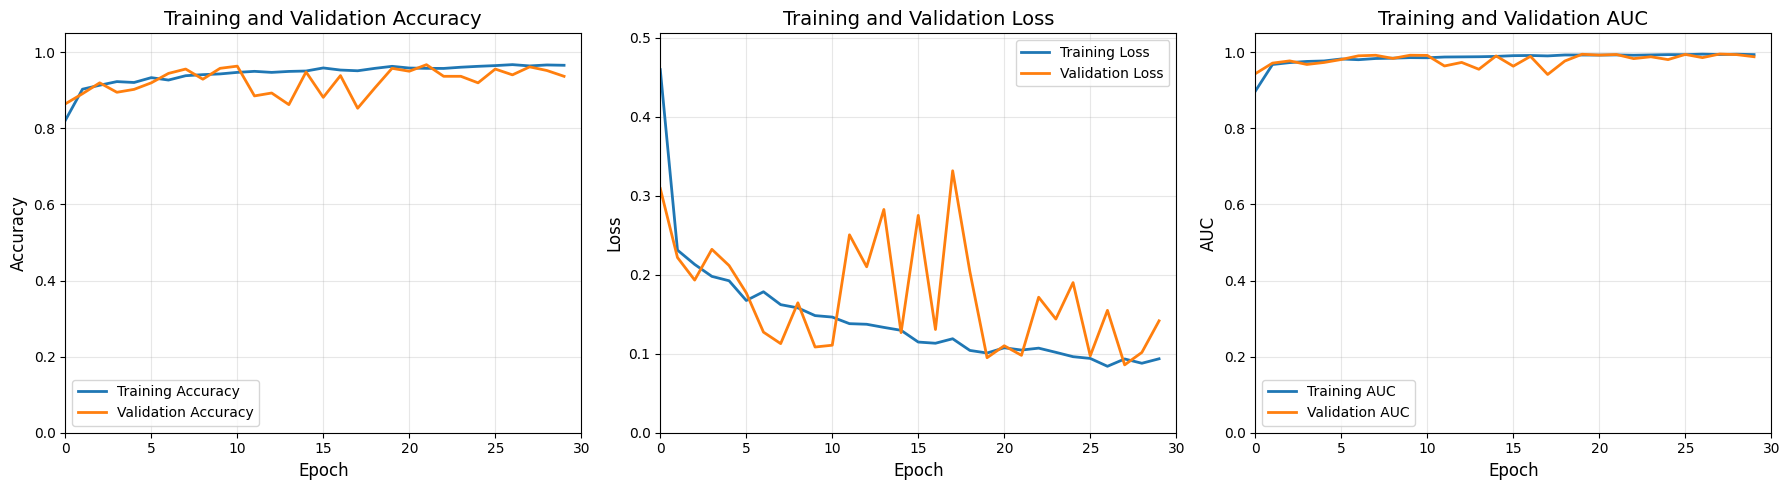

In [9]:
# Get callbacks for fine-tuning
callbacks = get_callbacks(
    tuned_model_path,
    monitor='val_AUC',
    mode='max',
    patience=10,
    factor=0.5  # Use lower factor for fine-tuning (more aggressive LR reduction)
)

# Start fine-tuning
print(f"\nStarting fine-tuning for {FINE_TUNE_EPOCHS} epochs...")
start_time = time.time()

history = adapted_model.fit(
    train_dataset,
    validation_data=(val_images, val_labels),
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks,
    verbose=tf_verbosity
)

exec_time = round(time.time() - start_time, 2)
print(f"\nFine-tuning completed in {exec_time} seconds")

# Save training info to logger
logger.add_training_info(history, exec_time)

# Set final model for evaluation
final_model = adapted_model

print("✓ Fine-tuning completed successfully!")

# Plot training history
plot_training_history(history)

# Model Evaluation


Evaluating fine-tuned model on test set...
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 303ms/step - AUC: 0.9583 - accuracy: 0.9160 - loss: 0.3223
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 256ms/step


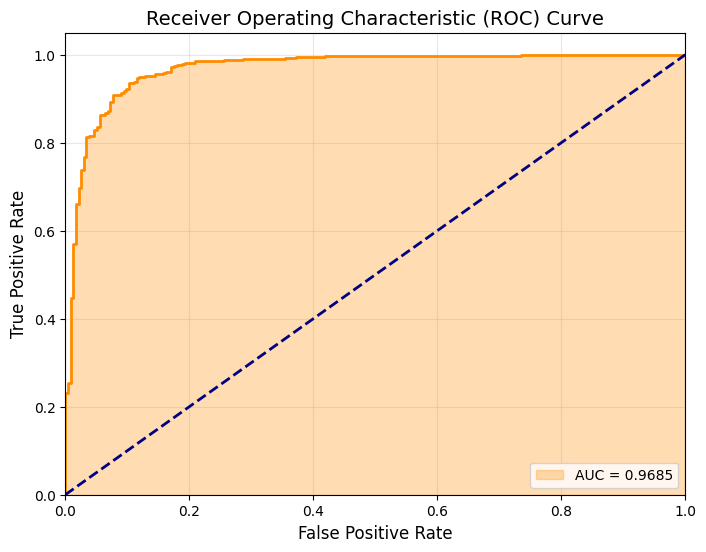

ROC AUC Score: 0.968486


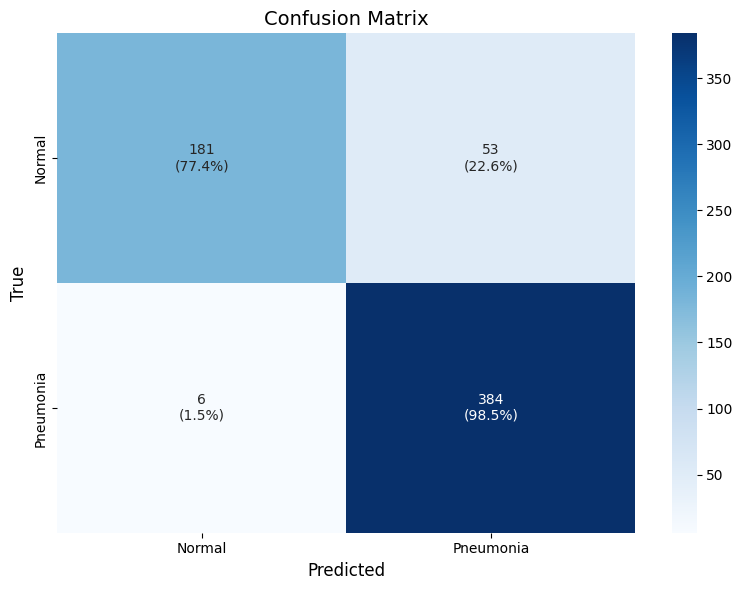


Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.77      0.86       234
   Pneumonia       0.88      0.98      0.93       390

    accuracy                           0.91       624
   macro avg       0.92      0.88      0.89       624
weighted avg       0.91      0.91      0.90       624



In [10]:
# Evaluate the fine-tuned model (using model from memory)
print("\nEvaluating fine-tuned model on test set...")

# Evaluate using the final model
results = evaluate_model(final_model, test_images, test_labels, verbose=tf_verbosity)

# Add evaluation results to logger
logger.add_evaluation_results(results)

# Plot results
plot_roc_curve(results['roc']['fpr'], results['roc']['tpr'], results['roc']['auc'])
plot_confusion_matrix(results['confusion_matrix'])
print("\nClassification Report:")
print(results['classification_report'])

# Results Saving

In [11]:
# Save fine-tuning log
tuned_log_path = os.path.join(LOG_PATH, f"{ARCHITECTURE}_tuned_{TARGET_SIZE}px_info.json")
logger.save(tuned_log_path)

print(f"\n✅ Fine-tuning completed successfully!")
print(f"📁 Model saved: {tuned_model_path}")
print(f"📊 Logs saved: {tuned_log_path}")
print(f"🎯 Final accuracy: {results['test_accuracy']:.4f}")
print(f"📈 Final AUC: {results['test_auc']:.4f}")
print(f"🔍 The ResNet50 model is now ready for XAI analysis at {TARGET_SIZE}x{TARGET_SIZE} resolution.")

Run information saved to ../output/logs/resnet_50_tuned_128px_info.json

✅ Fine-tuning completed successfully!
📁 Model saved: ../output/models/resnet_50_tuned_augmented_b32_lr0.001_dr0.3_128px_pneumonia_model.keras
📊 Logs saved: ../output/logs/resnet_50_tuned_128px_info.json
🎯 Final accuracy: 0.9054
📈 Final AUC: 0.9577
🔍 The ResNet50 model is now ready for XAI analysis at 128x128 resolution.
